# Exploratory Data Analysis — Constitution Texts (PDF Corpus)

**Project:** Constitutions d'Afrique — PhD thesis contribution  
**Corpus:** 54 constitution texts extracted from constituteproject.org PDFs  
**Date:** 2026-03-20

## Goals

1. Corpus-level statistics: document lengths, language quality, structural patterns
2. Keyword frequency analysis: thesis-relevant terms across 54 countries
3. Heritage group × keyword cross-tabulation
4. Preamble-specific analysis (sovereignty rhetoric for Ch.1 S1)
5. Assess feasibility of NLP milestones (M2: preamble analysis, M6: extended coding)

In [1]:
# /// script
# requires-python = ">=3.13"
# dependencies = ["numpy", "pandas", "matplotlib", "seaborn", "openpyxl"]
# ///

import json
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font='serif', palette='muted')
plt.rcParams.update({'figure.figsize': (12, 6), 'figure.dpi': 120, 'font.family': 'serif'})

HERITAGE_COLORS = {
    'francophone': '#4a5a9a', 'anglophone': '#9a3a4a',
    'lusophone': '#2a7a5a', 'other': '#7a8088', 'mixed': '#7a8088',
}

PROJECT_DIR = Path('..') if Path('../src/data.js').exists() else Path('.')
CORPUS_DIR = PROJECT_DIR / 'data' / 'constitution_corpus'
PREAMBLE_DIR = PROJECT_DIR / 'data' / 'preamble_corpus'

# Load heritage data
with open(PROJECT_DIR / 'src' / 'data.js') as f:
    DATA = json.loads(f.read().split('const DATA = ')[1].rstrip(';\n'))

# Load extraction stats
with open(CORPUS_DIR / '_extraction_stats.json') as f:
    stats = json.load(f)

print(f'Corpus: {len(stats)} constitutions')
print(f'Preambles: {sum(1 for s in stats if s["has_preamble"])}')

Corpus: 54 constitutions
Preambles: 49


In [2]:
# Build corpus DataFrame — use the authoritative country mapping
df = pd.DataFrame(stats)

with open(PROJECT_DIR / 'scripts' / 'country_mapping.json') as f:
    EN_TO_FR = json.load(f)

heritage_map = DATA['colonial_heritage']

def get_heritage(en_country):
    fr = EN_TO_FR.get(en_country)
    return heritage_map.get(fr, 'unknown') if fr else 'unknown'

def get_fr_name(en_country):
    return EN_TO_FR.get(en_country, en_country)

df['heritage'] = df['country'].apply(get_heritage)
df['fr_name'] = df['country'].apply(get_fr_name)
# Also build file→heritage lookup for downstream cells
filename_to_heritage = {s['file']: get_heritage(s['country']) for s in stats}

# Check for unmapped
unmapped = df[df['heritage'] == 'unknown']['country'].tolist()
if unmapped:
    print(f'WARNING: Unmapped countries: {unmapped}')
else:
    print('All 54 countries mapped.')

print(f'\nHeritage distribution:')
print(df['heritage'].value_counts())
df[['country', 'fr_name', 'heritage', 'words', 'has_preamble', 'preamble_words']].head(10)

All 54 countries mapped.

Heritage distribution:
heritage
francophone    23
anglophone     19
other           6
lusophone       5
mixed           1
Name: count, dtype: int64


,country,fr_name,heritage,words,has_preamble,preamble_words
0,Algeria,Algérie,francophone,19718,True,1381
1,Angola,Angola,lusophone,30535,True,635
2,Benin,Bénin,francophone,13424,True,491
3,Botswana,Botswana,anglophone,34586,False,0
4,Burkina Faso,Burkina Faso,francophone,15377,True,376
5,Burundi,Burundi,francophone,19125,True,378
6,Cameroon,Cameroun,mixed,10703,True,1077
7,Cape Verde,Cap-Vert,lusophone,33238,True,641
8,Central African Republic,République centrafricaine,francophone,17044,True,633
9,Chad,Tchad,francophone,15578,True,672


## 1. Corpus Statistics

/tmp/ipykernel_46747/1911378260.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_h, labels=heritage_present, patch_artist=True, widths=0.6)


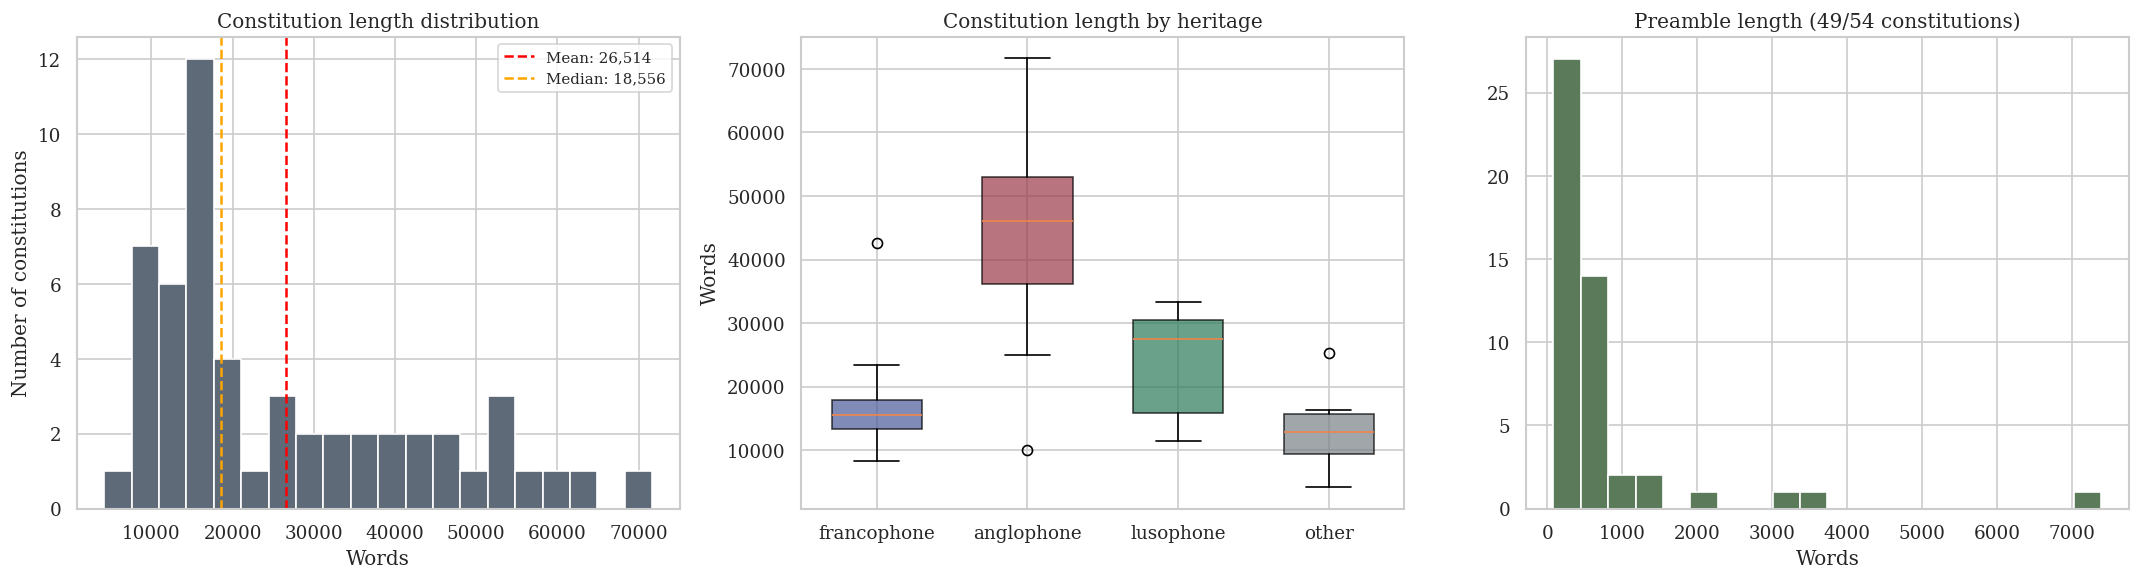

Constitution lengths: mean=26,514, median=18,556, range=[4,190–71,668]
Preamble lengths: mean=745, median=378

Without preamble: ['Botswana', 'Lesotho', 'Mauritius', 'Sierra Leone', 'Somalia']

Mean constitution length by heritage:
  francophone    :   16,486 words (n=23)
  anglophone     :   44,369 words (n=19)
  lusophone      :   23,719 words (n=5)
  other          :   13,382 words (n=6)


In [3]:
# Document length distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram of word counts
axes[0].hist(df['words'], bins=20, color='#5e6a78', edgecolor='white')
axes[0].axvline(df['words'].mean(), color='red', linestyle='--', label=f"Mean: {df['words'].mean():,.0f}")
axes[0].axvline(df['words'].median(), color='orange', linestyle='--', label=f"Median: {df['words'].median():,.0f}")
axes[0].set_xlabel('Words')
axes[0].set_ylabel('Number of constitutions')
axes[0].set_title('Constitution length distribution')
axes[0].legend(fontsize=9)

# By heritage
heritage_order = ['francophone', 'anglophone', 'lusophone', 'other']
heritage_present = [h for h in heritage_order if h in df['heritage'].values]
data_by_h = [df[df['heritage'] == h]['words'].values for h in heritage_present]
bp = axes[1].boxplot(data_by_h, labels=heritage_present, patch_artist=True, widths=0.6)
for patch, h in zip(bp['boxes'], heritage_present):
    patch.set_facecolor(HERITAGE_COLORS.get(h, '#999'))
    patch.set_alpha(0.7)
axes[1].set_ylabel('Words')
axes[1].set_title('Constitution length by heritage')

# Preamble lengths (only those with preambles)
with_p = df[df['has_preamble']]
axes[2].hist(with_p['preamble_words'], bins=20, color='#5a7a5a', edgecolor='white')
axes[2].set_xlabel('Words')
axes[2].set_title(f'Preamble length ({len(with_p)}/54 constitutions)')

plt.tight_layout()
plt.show()

print(f'Constitution lengths: mean={df["words"].mean():,.0f}, median={df["words"].median():,.0f}, range=[{df["words"].min():,}–{df["words"].max():,}]')
print(f'Preamble lengths: mean={with_p["preamble_words"].mean():.0f}, median={with_p["preamble_words"].median():.0f}')
print(f'\nWithout preamble: {df[~df["has_preamble"]]["country"].tolist()}')

# Heritage group means
print(f'\nMean constitution length by heritage:')
for h in heritage_present:
    subset = df[df['heritage'] == h]
    print(f'  {h:15s}: {subset["words"].mean():8,.0f} words (n={len(subset)})')

## 2. Keyword Frequency Analysis

In [4]:
# Load all full texts
texts = {}
for s in stats:
    path = CORPUS_DIR / f"{Path(s['file']).stem}.txt"
    texts[s['file']] = path.read_text(encoding='utf-8').lower()

# Thesis-relevant keyword groups
KEYWORD_GROUPS = {
    'peoples/groups': ['people', 'peoples', 'ethnic', 'tribe', 'tribal', 'community', 'communities', 'indigenous', 'minority', 'minorities'],
    'sovereignty/unity': ['sovereignty', 'sovereign', 'unity', 'indivisible', 'territorial integrity', 'national unity', 'one and indivisible'],
    'self-determination': ['self-determination', 'self determination', 'secession', 'autonomy', 'autonomous'],
    'rights': ['cultural rights', 'linguistic rights', 'minority rights', 'collective rights', 'group rights'],
    'institutions': ['decentralization', 'decentralisation', 'federal', 'federation', 'customary law', 'traditional authority', 'traditional leader', 'chief'],
    'land/resources': ['land', 'natural resources', 'territory', 'ancestral', 'communal land'],
    'language': ['official language', 'national language', 'mother tongue', 'vernacular'],
    'religion': ['secular', 'islam', 'christian', 'religion of the state', 'state religion', 'laïcité'],
}

# Count keywords per document
kw_counts = []
for s in stats:
    text = texts[s['file']]
    total_words = len(text.split())
    row = {'file': s['file'], 'country': s['country'], 'heritage': filename_to_heritage[s['file']], 'total_words': total_words}
    for group, keywords in KEYWORD_GROUPS.items():
        count = sum(len(re.findall(r'\b' + re.escape(kw) + r'\b', text)) for kw in keywords)
        row[f'{group}_count'] = count
        row[f'{group}_per1k'] = count / total_words * 1000 if total_words > 0 else 0
    kw_counts.append(row)

kw_df = pd.DataFrame(kw_counts)
print('Keywords computed for', len(kw_df), 'constitutions')

Keywords computed for 54 constitutions


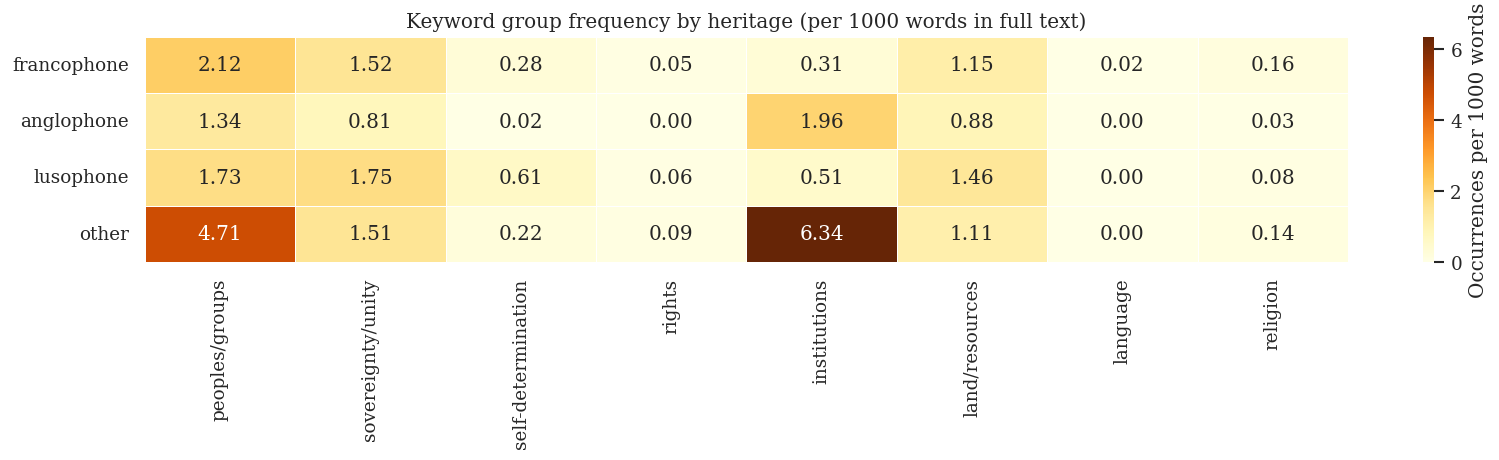

In [5]:
# Heritage group × keyword heatmap (per 1000 words)
per1k_cols = [c for c in kw_df.columns if c.endswith('_per1k')]
group_names = [c.replace('_per1k', '') for c in per1k_cols]

heritage_kw = kw_df.groupby('heritage')[per1k_cols].mean()
heritage_kw = heritage_kw.reindex([h for h in heritage_present if h in heritage_kw.index])
heritage_kw.columns = group_names

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(heritage_kw, annot=True, fmt='.2f', cmap='YlOrBr',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Occurrences per 1000 words'})
ax.set_title('Keyword group frequency by heritage (per 1000 words in full text)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

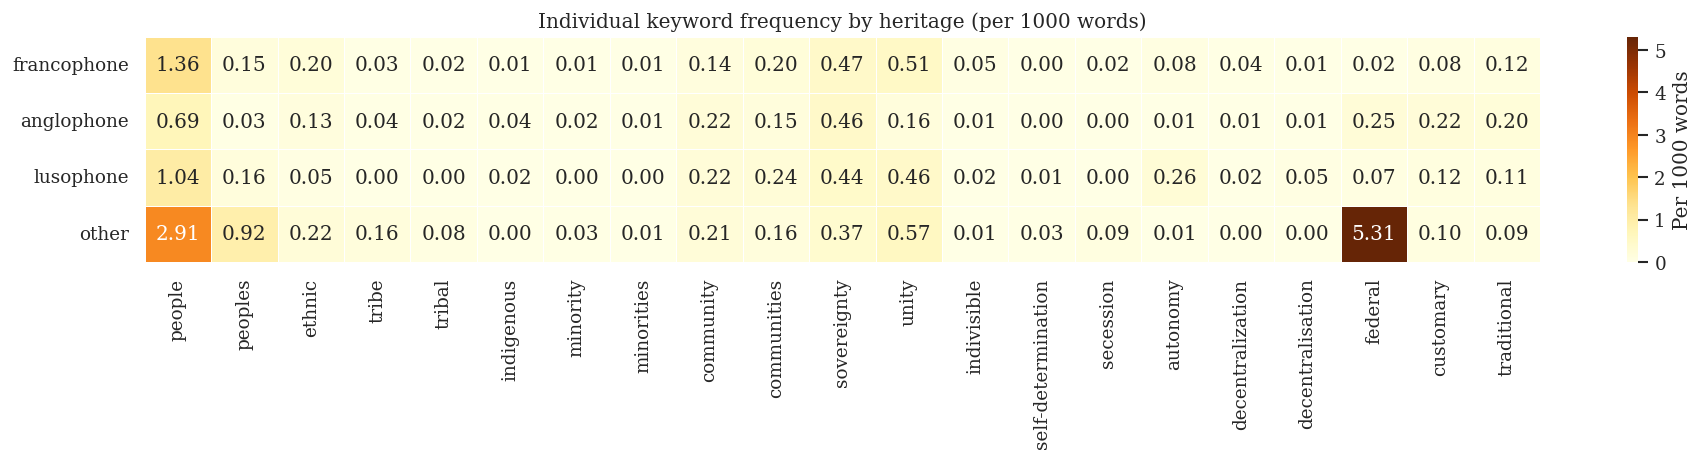


Keywords with largest francophone-anglophone gap:
  people                   : franco=1.36  anglo=0.69  gap=-0.67 (franco>)
  peoples                  : franco=0.15  anglo=0.03  gap=-0.12 (franco>)
  ethnic                   : franco=0.20  anglo=0.13  gap=-0.07 (franco>)
  community                : franco=0.14  anglo=0.22  gap=+0.08 (anglo>)
  unity                    : franco=0.51  anglo=0.16  gap=-0.36 (franco>)
  autonomy                 : franco=0.08  anglo=0.01  gap=-0.07 (franco>)
  federal                  : franco=0.02  anglo=0.25  gap=+0.23 (anglo>)
  customary                : franco=0.08  anglo=0.22  gap=+0.14 (anglo>)
  traditional              : franco=0.12  anglo=0.20  gap=+0.08 (anglo>)


In [6]:
# Individual keyword frequencies — the most thesis-relevant terms
INDIVIDUAL_KEYWORDS = [
    'people', 'peoples', 'ethnic', 'tribe', 'tribal', 'indigenous',
    'minority', 'minorities', 'community', 'communities',
    'sovereignty', 'unity', 'indivisible',
    'self-determination', 'secession', 'autonomy',
    'decentralization', 'decentralisation', 'federal',
    'customary', 'traditional',
]

individual_counts = []
for s in stats:
    text = texts[s['file']]
    total_words = len(text.split())
    row = {'country': s['country'], 'heritage': filename_to_heritage[s['file']]}
    for kw in INDIVIDUAL_KEYWORDS:
        count = len(re.findall(r'\b' + re.escape(kw) + r'\b', text))
        row[kw] = count / total_words * 1000 if total_words > 0 else 0
    individual_counts.append(row)

ikw = pd.DataFrame(individual_counts)

# Heritage means for individual keywords
heritage_ikw = ikw.groupby('heritage')[INDIVIDUAL_KEYWORDS].mean()
heritage_ikw = heritage_ikw.reindex([h for h in heritage_present if h in heritage_ikw.index])

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(heritage_ikw, annot=True, fmt='.2f', cmap='YlOrBr',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Per 1000 words'})
ax.set_title('Individual keyword frequency by heritage (per 1000 words)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# Which keywords differ most between francophone and anglophone?
print('\nKeywords with largest francophone-anglophone gap:')
for kw in INDIVIDUAL_KEYWORDS:
    fr = heritage_ikw.loc['francophone', kw] if 'francophone' in heritage_ikw.index else 0
    an = heritage_ikw.loc['anglophone', kw] if 'anglophone' in heritage_ikw.index else 0
    gap = an - fr
    if abs(gap) > 0.05:
        direction = 'anglo>' if gap > 0 else 'franco>'
        print(f'  {kw:25s}: franco={fr:.2f}  anglo={an:.2f}  gap={gap:+.2f} ({direction})')

## 3. Preamble Analysis (Ch.1 S1 Preview)

Loaded 49 preambles


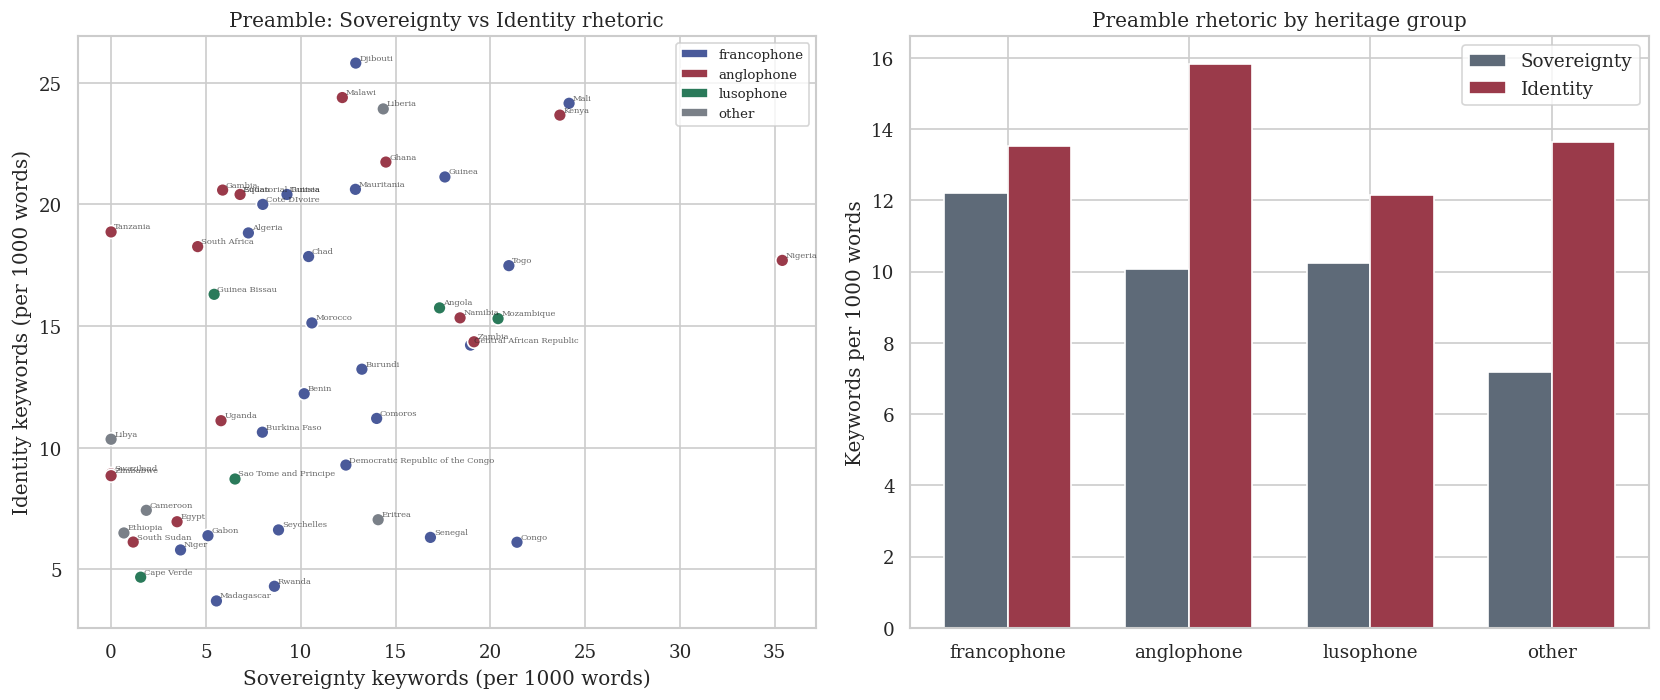

Heritage means (preambles):
             sovereignty_per1k  identity_per1k
heritage                                      
francophone              12.21           13.54
anglophone               10.07           15.82
lusophone                10.25           12.15
other                     7.18           13.64


In [7]:
# Load preambles
preambles = {}
for s in stats:
    if s['has_preamble']:
        path = PREAMBLE_DIR / f"{Path(s['file']).stem}.txt"
        if path.exists():
            preambles[s['file']] = path.read_text(encoding='utf-8').lower()

print(f'Loaded {len(preambles)} preambles')

# Sovereignty vs identity keywords in preambles
SOVEREIGNTY_KW = ['sovereignty', 'sovereign', 'unity', 'indivisible', 'territorial integrity',
                  'national unity', 'one and indivisible', 'unitary']
IDENTITY_KW = ['people', 'peoples', 'ethnic', 'tribe', 'tribal', 'diversity',
               'community', 'communities', 'indigenous', 'minority', 'minorities',
               'identity', 'cultural heritage', 'tradition']

preamble_analysis = []
for s in stats:
    if s['file'] not in preambles:
        continue
    text = preambles[s['file']]
    n_words = len(text.split())
    sov_count = sum(len(re.findall(r'\b' + re.escape(kw) + r'\b', text)) for kw in SOVEREIGNTY_KW)
    id_count = sum(len(re.findall(r'\b' + re.escape(kw) + r'\b', text)) for kw in IDENTITY_KW)
    preamble_analysis.append({
        'country': s['country'],
        'heritage': filename_to_heritage[s['file']],
        'preamble_words': n_words,
        'sovereignty_count': sov_count,
        'identity_count': id_count,
        'sovereignty_per1k': sov_count / n_words * 1000 if n_words > 0 else 0,
        'identity_per1k': id_count / n_words * 1000 if n_words > 0 else 0,
    })

pa = pd.DataFrame(preamble_analysis)

# Scatter: sovereignty vs identity in preambles
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = [HERITAGE_COLORS.get(h, '#999') for h in pa['heritage']]
ax1.scatter(pa['sovereignty_per1k'], pa['identity_per1k'], c=colors, s=60, edgecolors='white')
for _, row in pa.iterrows():
    ax1.annotate(row['country'], (row['sovereignty_per1k'], row['identity_per1k']),
                 fontsize=5, alpha=0.7, xytext=(2, 2), textcoords='offset points')
ax1.set_xlabel('Sovereignty keywords (per 1000 words)')
ax1.set_ylabel('Identity keywords (per 1000 words)')
ax1.set_title('Preamble: Sovereignty vs Identity rhetoric')
from matplotlib.patches import Patch
ax1.legend(handles=[Patch(facecolor=HERITAGE_COLORS[h], label=h) for h in heritage_present], fontsize=8)

# Heritage group means
heritage_pa = pa.groupby('heritage')[['sovereignty_per1k', 'identity_per1k']].mean()
heritage_pa = heritage_pa.reindex([h for h in heritage_present if h in heritage_pa.index])
x = range(len(heritage_pa))
w = 0.35
ax2.bar([i - w/2 for i in x], heritage_pa['sovereignty_per1k'], w, label='Sovereignty', color='#5e6a78')
ax2.bar([i + w/2 for i in x], heritage_pa['identity_per1k'], w, label='Identity', color='#9a3a4a')
ax2.set_xticks(list(x))
ax2.set_xticklabels(heritage_pa.index)
ax2.set_ylabel('Keywords per 1000 words')
ax2.set_title('Preamble rhetoric by heritage group')
ax2.legend()

plt.tight_layout()
plt.show()

print('Heritage means (preambles):')
print(heritage_pa.round(2))

In [8]:
# Countries with highest sovereignty rhetoric / lowest identity rhetoric
pa['sov_id_ratio'] = pa['sovereignty_per1k'] / (pa['identity_per1k'] + 0.1)  # avoid div by zero

print('Countries with HIGHEST sovereignty / identity ratio (sovereignty-dominant preambles):')
for _, row in pa.nlargest(10, 'sov_id_ratio').iterrows():
    print(f"  {row['country']:30s} [{row['heritage']:12s}] sov={row['sovereignty_per1k']:.1f} id={row['identity_per1k']:.1f}")

print('\nCountries with LOWEST ratio (identity-dominant preambles):')
for _, row in pa.nsmallest(10, 'sov_id_ratio').iterrows():
    print(f"  {row['country']:30s} [{row['heritage']:12s}] sov={row['sovereignty_per1k']:.1f} id={row['identity_per1k']:.1f}")

Countries with HIGHEST sovereignty / identity ratio (sovereignty-dominant preambles):
  Congo                          [francophone ] sov=21.4 id=6.1
  Senegal                        [francophone ] sov=16.8 id=6.3
  Nigeria                        [anglophone  ] sov=35.4 id=17.7
  Eritrea                        [other       ] sov=14.1 id=7.0
  Rwanda                         [francophone ] sov=8.6 id=4.3
  Madagascar                     [francophone ] sov=5.6 id=3.7
  Mozambique                     [lusophone   ] sov=20.4 id=15.3
  Zambia                         [anglophone  ] sov=19.1 id=14.4
  Central African Republic       [francophone ] sov=19.0 id=14.2
  Democratic Republic of the Congo [francophone ] sov=12.4 id=9.3

Countries with LOWEST ratio (identity-dominant preambles):
  Libya                          [other       ] sov=0.0 id=10.3
  Swaziland                      [anglophone  ] sov=0.0 id=8.9
  Tanzania                       [anglophone  ] sov=0.0 id=18.9
  Zimbabwe         

## 4. Self-Determination Language (Ch.5 Preview)

In [9]:
# Classify constitutions by self-determination posture
sd_analysis = []
for s in stats:
    text = texts[s['file']]
    country = s['country']
    heritage = filename_to_heritage[s['file']]
    
    has_sd = bool(re.search(r'self.determination', text))
    has_secession = bool(re.search(r'\bsecessi', text))
    prohibits_secession = bool(re.search(r'(?:prohibit|forbid|shall not|no right).{0,30}secess', text)) or \
                         bool(re.search(r'secess.{0,30}(?:prohibit|forbid|not permit)', text))
    has_autonomy = bool(re.search(r'\bautonomy\b|\bautonomous\b', text))
    has_indivisible = bool(re.search(r'\bindivisible\b', text))
    
    # Classify
    if has_sd and not prohibits_secession and country == 'Ethiopia':
        posture = 'permits external SD'
    elif has_sd or has_autonomy:
        posture = 'internal SD / autonomy'
    elif has_secession and prohibits_secession:
        posture = 'prohibits secession'
    elif has_indivisible:
        posture = 'indivisible (implicit prohibition)'
    else:
        posture = 'silent'
    
    sd_analysis.append({
        'country': country, 'heritage': heritage,
        'has_self_determination': has_sd, 'has_secession': has_secession,
        'prohibits_secession': prohibits_secession, 'has_autonomy': has_autonomy,
        'has_indivisible': has_indivisible, 'posture': posture,
    })

sd = pd.DataFrame(sd_analysis)

print('Self-determination posture distribution:')
print(sd['posture'].value_counts())

print('\nBy heritage group:')
ct = pd.crosstab(sd['heritage'], sd['posture'])
ct = ct.reindex([h for h in heritage_present if h in ct.index])
print(ct)

# Key flags
print(f"\nConstitutions mentioning 'self-determination': {sd['has_self_determination'].sum()}/54")
print(f"Constitutions mentioning 'secession': {sd['has_secession'].sum()}/54")
print(f"Constitutions with 'indivisible': {sd['has_indivisible'].sum()}/54")
print(f"Constitutions with 'autonomy/autonomous': {sd['has_autonomy'].sum()}/54")

Self-determination posture distribution:
posture
internal SD / autonomy                32
silent                                14
indivisible (implicit prohibition)     7
permits external SD                    1
Name: count, dtype: int64

By heritage group:
posture      indivisible (implicit prohibition)  internal SD / autonomy  \
heritage                                                                  
francophone                                   4                      18   
anglophone                                    2                       6   
lusophone                                     0                       5   
other                                         1                       2   

posture      permits external SD  silent  
heritage                                  
francophone                    0       1  
anglophone                     0      11  
lusophone                      0       0  
other                          1       2  

Constitutions mentioning 'self-

## 5. Summary

In [10]:
print('='*60)
print('CORPUS EDA SUMMARY')
print('='*60)

print(f'\n1. CORPUS: {len(stats)} constitutions, {sum(s["words"] for s in stats):,} total words')
print(f'   Mean length: {df["words"].mean():,.0f} words')
print(f'   Anglophone constitutions are longer ({df[df["heritage"]=="anglophone"]["words"].mean():,.0f}) than francophone ({df[df["heritage"]=="francophone"]["words"].mean():,.0f})')

print(f'\n2. PREAMBLES: {len(preambles)}/54 extracted')
print(f'   Without preamble: {df[~df["has_preamble"]]["country"].tolist()}')

print(f'\n3. KEYWORD PATTERNS')
print(f'   See heritage × keyword heatmaps above')

print(f'\n4. SELF-DETERMINATION')
print(f'   {sd["has_self_determination"].sum()}/54 mention self-determination')
print(f'   {sd["has_indivisible"].sum()}/54 declare indivisibility')
print(f'   Only Ethiopia permits external self-determination (secession)')

print(f'\n5. IMPLICATIONS')
print(f'   M2 (preamble NLP): feasible — 49 preambles with substantial text')
print(f'   M2 (self-determination): keyword approach yields initial classification, may need manual review')
print(f'   M6 (extended coding): full texts available for NLP on land/resources/cultural rights')

CORPUS EDA SUMMARY

1. CORPUS: 54 constitutions, 1,431,765 total words
   Mean length: 26,514 words
   Anglophone constitutions are longer (44,369) than francophone (16,486)

2. PREAMBLES: 49/54 extracted
   Without preamble: ['Botswana', 'Lesotho', 'Mauritius', 'Sierra Leone', 'Somalia']

3. KEYWORD PATTERNS
   See heritage × keyword heatmaps above

4. SELF-DETERMINATION
   8/54 mention self-determination
   24/54 declare indivisibility
   Only Ethiopia permits external self-determination (secession)

5. IMPLICATIONS
   M2 (preamble NLP): feasible — 49 preambles with substantial text
   M2 (self-determination): keyword approach yields initial classification, may need manual review
   M6 (extended coding): full texts available for NLP on land/resources/cultural rights
